# Introducción

Este notebook entrena un modelo de clasificación de sentimientos en español usando el dataset de opiniones turísticas. Se incluyen métricas, visualizaciones, análisis de errores y recomendaciones para mejorar el desempeño del modelo.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix


/home/andresmtr/miniconda3/envs/PruebaBRM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carge de datos

In [2]:
raw_data = load_dataset("alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad")
data = raw_data['train']

In [3]:
# Visualizar los primeros ejemplos como si fuera pandas
print("\nPrimeros 5 registros del dataset:")
print(pd.DataFrame(data[:5]))


Primeros 5 registros del dataset:
                                                text  label
0  el mejor lugar para comer sushi. excelente lug...      5
1  vista hermosa!. me sorprendió la maravillosa v...      5
2  desastroso. buenas noches,  ante todo explicar...      1
3  todo bien excepto que se niegan a dar vasos de...      3
4  el mejor zoologico de méxico. el ambiente es m...      5


In [4]:
# Ajustar etiquetas de 1-5 a 0-4
def adjust_labels(example):
    example["label"] = example["label"] - 1
    return example

# Preparar los datos para la tokenizacion

In [5]:
tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-bne")

In [6]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

In [7]:
# Preprocesamiento
processed = data.map(adjust_labels)
processed = processed.map(tokenize, batched=True)
processed.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [8]:
# Separar datos
train_data, test_data = processed.train_test_split(test_size=0.2, seed=42).values()

In [9]:
# DataLoaders

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

# Cargar modelo preeentrenado

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "PlanTL-GOB-ES/roberta-base-bne",
    num_labels=5  # Etiquetas de 1 a 5
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at PlanTL-GOB-ES/roberta-base-bne and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Configurar optmizador, la perdida y uso de CUDA

In [11]:
optimizer = AdamW(model.parameters(), lr=1e-5)

In [12]:
num_training_steps = len(train_loader) * 5  # 5 = número de épocas
scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [13]:
# Activar CUDA Launch Blocking para depuración
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [14]:
# Verificacion del uso de cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50262, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

# Entrenamiento

In [ ]:
train_losses = []
model.train()
for epoch in range(5):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    epoch_loss = 0
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))


Epoch 4:   2%|▏         | 194/8810 [00:18<13:25, 10.69it/s]

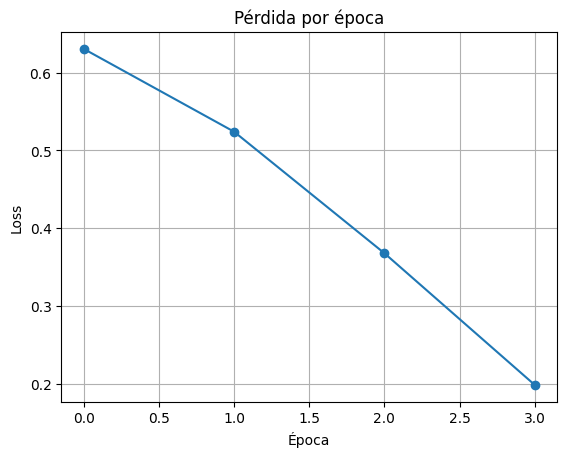

In [ ]:
# Paso 5: Visualización de la pérdida
plt.plot(train_losses, marker='o')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Evaluacion

In [ ]:
model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        trues.extend(labels.cpu().numpy())

# Clasificación
print(classification_report(trues, preds, digits=3))

              precision    recall  f1-score   support

           0      0.650     0.637     0.643       776
           1      0.426     0.423     0.424       994
           2      0.608     0.514     0.557      3052
           3      0.510     0.470     0.489      8354
           4      0.824     0.867     0.845     22063

    accuracy                          0.725     35239
   macro avg      0.604     0.582     0.592     35239
weighted avg      0.716     0.725     0.719     35239



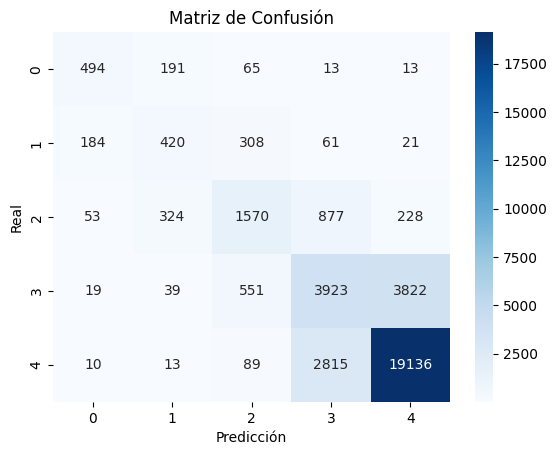

In [ ]:

# Matriz de confusión
cm = confusion_matrix(trues, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
wrong = [(p, t, s) for p, t, s in zip(preds, trues, test_data['text']) if p != t]
print("\nEjemplos de errores de clasificación:\n")
for p, t, s in wrong[:200]:
    print(f"Texto: {s[:100]}...\nPredicho: {p} | Real: {t}\n")


Ejemplos de errores de clasificación:

Texto: descansa y camina. en el corazón angelopolitano, excelente ubicación para descansar luego de recorre...
Predicho: 4 | Real: 3

Texto: la historia es aquí. qué contraste de la vieja habana y la ciudad de la habana es viejo y pobres, es...
Predicho: 4 | Real: 3

Texto: increíble ambiente. me encantó este lugar. la música es fantástico y la comida es lo suficientemente...
Predicho: 4 | Real: 3

Texto: muy buena experiencia. excelente lugar, con una ambientación muy agradable para ir en pareja o con a...
Predicho: 3 | Real: 4

Texto: hermosa ciudad amurallada. mucha historia en la cuidad amurallada, su arquitectura, sus luces, sus c...
Predicho: 4 | Real: 3

Texto: lo mejor: la música en vivo. cuando el plan es disfutar de música cubana en vivo y tomarte un par de...
Predicho: 3 | Real: 2

Texto: no hay que perderselo!. sito de historia, logren ingresar con un guía para que sea mas enriquecedora...
Predicho: 4 | Real: 3

Texto: gran lugar para

In [ ]:
model.save_pretrained("modelo-turismo-sentimientos")
tokenizer.save_pretrained("modelo-turismo-sentimientos")

('modelo-turismo-sentimientos/tokenizer_config.json',
 'modelo-turismo-sentimientos/special_tokens_map.json',
 'modelo-turismo-sentimientos/vocab.json',
 'modelo-turismo-sentimientos/merges.txt',
 'modelo-turismo-sentimientos/added_tokens.json',
 'modelo-turismo-sentimientos/tokenizer.json')

# Comentarios finales: